In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../external-data/train.csv', index_col='Id')
X_test_full = pd.read_csv('../external-data/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# drop outliers areas
outlier_idx = X_full[(X_full['GrLivArea'] > 4000) & (y < 300000)].index
X_full = X_full.drop(outlier_idx)
y = y.drop(outlier_idx)

# original 3-feature set -- superseded below after a CV ablation experiment
# (see the feature-engineering-experiment cells at the end of the notebook)
# for df in (X_full, X_test_full):
#     df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
#     df['HouseAge'] = df['YrSold'] - df['YearBuilt']
#     df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath']
#                         + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# Feature set chosen by 5x5 repeated-CV ablation (see experiment cells at the end
# of the notebook): kept TotalSF, HouseAge, RemodAge, TotalBath, an
# OverallQual x GrLivArea interaction, and GarageAge. Dropped candidates that
# didn't earn their keep: TotalPorchSF (no measurable effect on CV MAE) and an
# OverallQual x TotalSF interaction (redundant with TotalSF, net negative).
# Repeated-CV MAE: no engineered features 15804, original 3 above 15577, this set 15394.
for df in (X_full, X_test_full):
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath']
                        + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    df['OverallQual_GrLivArea'] = df['OverallQual'] * df['GrLivArea']
    df['GarageAge'] = (df['YrSold'] - df['GarageYrBlt']).where(df['GarageYrBlt'] > 0, 0)

# Break off validation set from training data (80/20 split on 1460 rows)
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_full, y, 
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)


# Select categorical columns with relatively low cardinality (convenient but arbitrary)
# categorical_cols = [cname for cname in X_train_full.columns if
#                     X_train_full[cname].nunique() < 10 and 
#                     X_train_full[cname].dtype == "object"]

# No dropping
categorical_cols = [cname for cname in X_train_full.columns if
                    X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if 
                X_train_full[cname].dtype in ['int64', 'float64']]


# Columns that just should have 'None' in spite of NaN
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for df in (X_train_full, X_valid_full, X_test_full):
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

quality_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
            
onehot_cols = [c for c in categorical_cols if c not in quality_cols]

# Explicit ordered categories for the Po/Fa/TA/Gd/Ex quality scale, one list per
# quality column, so OrdinalEncoder preserves the scale's ordering instead of
# encoding it alphabetically. Columns filled with 'None' above get 'None' as
# the lowest rank; the rest use the plain 5-point scale.
quality_scale_full = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
quality_scale_no_none = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

quality_orders = {
    col: quality_scale_full if col in none_cols else quality_scale_no_none
    for col in quality_cols
}

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

In [2]:
X_train.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,PoolArea,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodAge,TotalBath,OverallQual_GrLivArea,GarageAge
Id,,,,,,,,,,,,,,,,,,,,,
1172,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,0,1400,11,2008,2522,50,50,2.0,7566,50.0
76,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,0,0,11,2009,1450,36,36,2.0,3952,36.0
391,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,...,0,0,4,2008,2228,108,58,2.0,6835,30.0
1284,RL,Pave,None,Reg,Low,AllPub,Corner,Gtl,Mitchel,Norm,...,0,0,4,2010,2736,39,39,3.0,10944,0.0
684,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,CollgCr,Norm,...,0,0,7,2007,3294,5,5,3.0,15012,5.0


In [3]:
# apply xgboost

from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_absolute_error

# Preprocessing for numerical data
numerical_transformer = SimpleImputer()

# Preprocessing for nominal (unordered) categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessing for ordinal quality data, using the Po/Fa/TA/Gd/Ex scale order
# built into quality_orders so ranks are preserved instead of alphabetized
quality_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[quality_orders[c] for c in quality_cols],
                                handle_unknown='use_encoded_value', unknown_value=-1))
])

# Bundle preprocessing for numerical, one-hot, and ordinal quality data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, onehot_cols),
        ('qual', quality_transformer, quality_cols)
    ])

model = XGBRegressor(n_estimators=1000, learning_rate=0.05,  early_stopping_rounds=10, eval_metric='mae', max_depth=3, subsample=0.6, colsample_bytree=0.6, min_child_weight=3, random_state=0)

xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('model', model)])

# fit preprocessor on train, transform valid so eval_set matches the model's input space
X_valid_transformed = xgb_pipeline.named_steps['preprocessor'].fit(X_train).transform(X_valid)

xgb_pipeline.fit(X_train, y_train,
                  model__eval_set=[(X_valid_transformed, y_valid)],
                  model__verbose=False)

pred = xgb_pipeline.predict(X_valid)

# calculate training MAE
mae = mean_absolute_error(pred, y_valid)
print("Mean Absolute Error:" , mae)


Mean Absolute Error: 14496.8701171875


In [4]:
preds_test = xgb_pipeline.predict(X_test)

In [5]:
output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': preds_test})
output.to_csv('submission-xgboost-last.csv', index=False)

# Experiments:

In [6]:
# Repeated CV: run 5-fold CV 5 separate times with different shuffles (25 fits
# total) to see how much the MAE estimate itself moves around, before trusting
# any single CV number enough to act on it. With only ~1450 rows, a single
# 5-fold pass already showed fold scores swinging from ~13927 to ~16786 --
# repeating the split many times over averages that split-luck out.
#
# Note: this uses a fixed n_estimators (no early stopping) because
# cross_val_score can't supply a fold-specific eval_set, which early stopping
# requires -- see the "aligned" cells below for the early-stopping version of
# this same experiment, run on the actual submission model's config.
from sklearn.model_selection import RepeatedKFold, cross_val_score

repeated_cv_model = XGBRegressor(n_estimators=300, learning_rate=0.05,
                                  eval_metric='mae', random_state=0)
repeated_cv_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('model', repeated_cv_model)])

rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)
repeated_scores = -1 * cross_val_score(repeated_cv_pipeline, X_full, y,
                                        cv=rkf, scoring='neg_mean_absolute_error')

print("Repeated CV MAE: mean =", repeated_scores.mean(), " std =", repeated_scores.std())
print("min =", repeated_scores.min(), " max =", repeated_scores.max())

Repeated CV MAE: mean = 15354.5094140625  std = 779.2820366873726
min = 13470.4140625  max = 16967.306640625


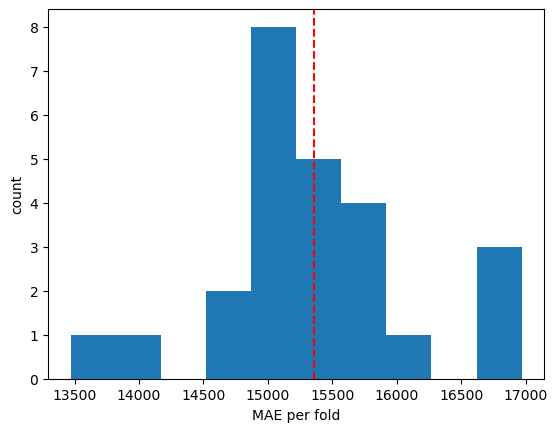

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.hist(repeated_scores, bins=10)
plt.axvline(repeated_scores.mean(), color='red', linestyle='--')
plt.xlabel('MAE per fold')
plt.ylabel('count')
plt.show()

**Note on nested CV:** repeated K-fold above re-estimates the *same, fixed* model config many times, which is enough as long as no hyperparameter is being chosen from these same folds. If a hyperparameter sweep (e.g. `learning_rate`) is added later and its winner is reported using the score it won with, that score is optimistically biased -- the model got to see those folds during selection. Nested CV (outer folds for the final MAE estimate, inner folds for picking the hyperparameter within each outer fold) is what guards against that. Not needed yet since nothing is being tuned here, but worth adding before trusting a tuned MAE number.

## Aligning the CV baseline with the actual submission model

The repeated-CV baseline above was measured on a config that doesn't match the
submission model in the setup cell (`n_estimators=1000, learning_rate=0.05,
early_stopping_rounds=10`), which itself was only ever scored on a single
fixed 80/20 split, with no variance estimate. `cross_val_score` can't fix this
directly: when `early_stopping_rounds` is set, XGBoost requires an `eval_set`
at fit time, and that eval set must be *this fold's* held-out rows, transformed
by a preprocessor fit only on *this fold's* training rows -- a per-fold fit
param that `cross_val_score`/`Pipeline.fit_params` has no way to supply. So the
cell below re-runs the same `RepeatedKFold(5, 5)` split (same seed as above,
for a direct comparison) with a manual loop that fits early stopping correctly
per fold.

In [8]:
from sklearn.base import clone

def aligned_cv_score(rkf, **xgb_params):
    """Repeated-CV MAE for an XGBRegressor with early stopping fit per fold
    (the manual loop cross_val_score can't do, since it can't supply a
    fold-specific eval_set). Returns (scores, best_iterations), one entry
    per split in rkf."""
    scores = []
    best_iterations = []

    for train_idx, valid_idx in rkf.split(X_full, y):
        X_train_fold, X_valid_fold = X_full.iloc[train_idx], X_full.iloc[valid_idx]
        y_train_fold, y_valid_fold = y.iloc[train_idx], y.iloc[valid_idx]

        fold_preprocessor = clone(preprocessor)
        X_train_fold_t = fold_preprocessor.fit_transform(X_train_fold)
        X_valid_fold_t = fold_preprocessor.transform(X_valid_fold)

        fold_model = XGBRegressor(**xgb_params)
        fold_model.fit(X_train_fold_t, y_train_fold,
                        eval_set=[(X_valid_fold_t, y_valid_fold)],
                        verbose=False)

        fold_pred = fold_model.predict(X_valid_fold_t)
        scores.append(mean_absolute_error(fold_pred, y_valid_fold))
        best_iterations.append(fold_model.best_iteration)

    return np.array(scores), np.array(best_iterations)

DEFAULT_XGB_PARAMS = dict(n_estimators=1000, learning_rate=0.05,
                           early_stopping_rounds=10, eval_metric='mae', random_state=0)

aligned_scores, aligned_best_iterations = aligned_cv_score(rkf, **DEFAULT_XGB_PARAMS)

Aligned repeated CV MAE (n_estimators=1000, early_stopping_rounds=10):
mean = 15369.4810546875  std = 782.3306653080671
min = 13458.2783203125  max = 16996.583984375

best_iteration across folds: mean = 214.08  min = 138  max = 369


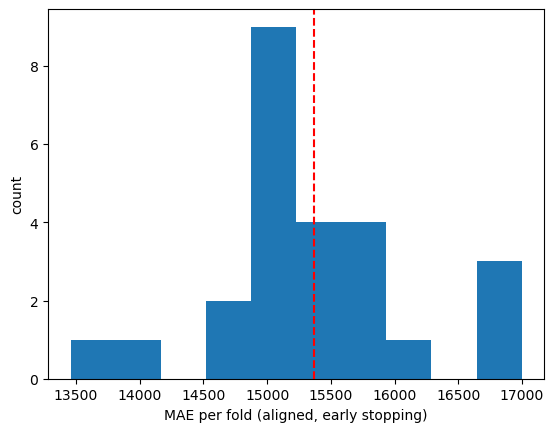

In [9]:
print("Aligned repeated CV MAE (n_estimators=1000, early_stopping_rounds=10):")
print("mean =", aligned_scores.mean(), " std =", aligned_scores.std())
print("min =", aligned_scores.min(), " max =", aligned_scores.max())
print()
print("best_iteration across folds: mean =", aligned_best_iterations.mean(),
      " min =", aligned_best_iterations.min(),
      " max =", aligned_best_iterations.max())

plt.hist(aligned_scores, bins=10)
plt.axvline(aligned_scores.mean(), color='red', linestyle='--')
plt.xlabel('MAE per fold (aligned, early stopping)')
plt.ylabel('count')
plt.show()

## Hyperparameter sweep: max_depth, min_child_weight, subsample, colsample_bytree

`n_estimators`/`learning_rate` aren't really free parameters here -- early
stopping already picks the effective tree count per fold (`best_iteration`
above averages ~214, well under the 1000 cap), so tuning them further has
little room to help. The four untouched XGBoost defaults below are the actual
overfitting knobs for a ~1450-row, 85-column dataset: `max_depth` (default 6,
plausibly too deep), `min_child_weight` (default 1), and `subsample` /
`colsample_bytree` (both default 1.0, i.e. no row/column sampling at all).

Each value below is tested one at a time against the aligned baseline (mean
~15369, std ~782, printed above) from the cells above, holding every other
parameter at its default, using the same `aligned_cv_score` helper and the
*same* `RepeatedKFold` splits (`rkf`) for a direct, noise-matched comparison.
As with the feature-engineering ablation earlier, an improvement only counts
if it moves the mean by more than roughly one std -- otherwise it's within
fold-sampling noise.

Same nested-CV caveat as noted earlier applies to the combined "best of each"
result at the end: since every candidate value is scored on these same 25
folds, the winning combination's score is somewhat optimistic. Fine for
deciding what to change; not a substitute for a final untouched check before
trusting the tuned number.

In [10]:
sweep_grid = {
    'max_depth': [3, 4, 5, 6],           # 6 is XGBoost's default
    'min_child_weight': [1, 3, 5],       # 1 is XGBoost's default
    'subsample': [0.6, 0.8, 1.0],        # 1.0 is XGBoost's default
    'colsample_bytree': [0.6, 0.8, 1.0], # 1.0 is XGBoost's default
}

print(f"baseline: mean={aligned_scores.mean():.1f} std={aligned_scores.std():.1f}\n")

sweep_results = {}
for param, values in sweep_grid.items():
    print(f"=== {param} ===")
    param_results = {}
    for value in values:
        scores, _ = aligned_cv_score(rkf, **{**DEFAULT_XGB_PARAMS, param: value})
        param_results[value] = scores.mean()
        print(f"{param}={value:<5} mean={scores.mean():.1f} std={scores.std():.1f}")
    sweep_results[param] = param_results
    print()

baseline: mean=15369.5 std=782.3

=== max_depth ===
max_depth=3     mean=14717.7 std=890.2
max_depth=4     mean=14733.8 std=814.2
max_depth=5     mean=15089.5 std=916.8
max_depth=6     mean=15369.5 std=782.3

=== min_child_weight ===
min_child_weight=1     mean=15369.5 std=782.3
min_child_weight=3     mean=15302.5 std=845.4
min_child_weight=5     mean=15395.6 std=937.7

=== subsample ===
subsample=0.6   mean=14722.7 std=952.7
subsample=0.8   mean=14790.2 std=852.4
subsample=1.0   mean=15369.5 std=782.3

=== colsample_bytree ===
colsample_bytree=0.6   mean=14893.6 std=938.7
colsample_bytree=0.8   mean=15088.5 std=880.3
colsample_bytree=1.0   mean=15369.5 std=782.3



In [11]:
# Combine each parameter's individually-best value into one config and
# re-score it -- if a value is XGBoost's default, that parameter contributed
# nothing (no improvement was found for it).
best_per_param = {param: min(results, key=results.get) for param, results in sweep_results.items()}
print("Best individual value per parameter:", best_per_param)

combined_scores, combined_best_iterations = aligned_cv_score(rkf, **{**DEFAULT_XGB_PARAMS, **best_per_param})

print(f"\ncombined {best_per_param}")
print(f"  mean={combined_scores.mean():.1f} std={combined_scores.std():.1f}")
print(f"baseline (all defaults)")
print(f"  mean={aligned_scores.mean():.1f} std={aligned_scores.std():.1f}")

Best individual value per parameter: {'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.6, 'colsample_bytree': 0.6}

combined {'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.6, 'colsample_bytree': 0.6}
  mean=14485.1 std=974.8
baseline (all defaults)
  mean=15369.5 std=782.3


## Feature engineering experiment

Compares candidate engineered features via CV instead of guessing. Self-contained
(re-reads and rebuilds from the raw CSV) so it doesn't depend on the feature
columns the setup cell above already baked into `X_full`/`X_test_full`.

In [12]:
# Candidate engineered features to test, and a builder + CV scorer that can
# toggle any subset of them on top of the raw columns.
RAW = pd.read_csv('../external-data/train.csv', index_col='Id')
y_exp = RAW.SalePrice
RAW = RAW.drop(['SalePrice'], axis=1)

exp_outlier_idx = RAW[(RAW['GrLivArea'] > 4000) & (y_exp < 300000)].index
RAW = RAW.drop(exp_outlier_idx)
y_exp = y_exp.drop(exp_outlier_idx)

FEATURE_STEPS = [
    ('TotalSF', lambda df: df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']),
    ('HouseAge', lambda df: df['YrSold'] - df['YearBuilt']),
    ('RemodAge', lambda df: df['YrSold'] - df['YearRemodAdd']),
    ('TotalBath', lambda df: df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']),
    ('TotalPorchSF', lambda df: df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']),
    ('OverallQual_GrLivArea', lambda df: df['OverallQual'] * df['GrLivArea']),
    ('GarageAge', lambda df: (df['YrSold'] - df['GarageYrBlt']).where(df['GarageYrBlt'] > 0, 0)),
]

def build_features(active_features):
    df = RAW.copy()
    for name, fn in FEATURE_STEPS:
        if name in active_features:
            df[name] = fn(df)
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    return df

def cv_score(active_features, cv, n_estimators=300, learning_rate=0.05, seed=0):
    df = build_features(active_features)

    exp_categorical_cols = [c for c in df.columns if df[c].dtype == "object"]
    exp_numerical_cols = [c for c in df.columns if df[c].dtype in ['int64', 'float64']]
    exp_onehot_cols = [c for c in exp_categorical_cols if c not in quality_cols]

    exp_preprocessor = ColumnTransformer(transformers=[
        ('num', SimpleImputer(), exp_numerical_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                 ('onehot', OneHotEncoder(handle_unknown='ignore'))]), exp_onehot_cols),
        ('qual', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('ordinal', OrdinalEncoder(categories=[quality_orders[c] for c in quality_cols],
                                                              handle_unknown='use_encoded_value', unknown_value=-1))]), quality_cols),
    ])
    exp_model = XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, eval_metric='mae', random_state=seed)
    exp_pipe = Pipeline(steps=[('preprocessor', exp_preprocessor), ('model', exp_model)])

    scores = -1 * cross_val_score(exp_pipe, df, y_exp, cv=cv, scoring='neg_mean_absolute_error')
    return scores.mean(), scores.std()

In [13]:
# Cumulative ablation: add one candidate feature at a time, single 5-fold CV
# (fast pass to see direction of effect -- noisy, see the repeated-CV comparison below
# for the trustworthy numbers)
print("=== baseline (no engineered features) ===")
mean, std = cv_score([], cv=5)
print(f"mean={mean:.1f} std={std:.1f}")

print("\n=== cumulative ablation ===")
active = []
for name, _ in FEATURE_STEPS:
    active = active + [name]
    mean, std = cv_score(active, cv=5)
    print(f"+{name:<24} mean={mean:.1f} std={std:.1f}")

=== baseline (no engineered features) ===
mean=15582.8 std=807.9

=== cumulative ablation ===
+TotalSF                  mean=15881.9 std=978.1
+HouseAge                 mean=15699.4 std=1130.8
+RemodAge                 mean=15764.6 std=1075.2
+TotalBath                mean=15621.3 std=1092.0
+TotalPorchSF             mean=15709.1 std=1010.5
+OverallQual_GrLivArea    mean=15445.7 std=844.7
+GarageAge                mean=15431.4 std=878.1


In [14]:
# Trustworthy comparison: repeated 5x5-fold CV (same technique as the
# repeated-CV cells above) across the meaningful candidates -- this is what
# decided the feature set used in the setup cell.
rkf_exp = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)

winning_features = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'OverallQual_GrLivArea', 'GarageAge']

candidates = {
    'baseline (no engineered features)': [],
    'original 3 (TotalSF, HouseAge, TotalBath)': ['TotalSF', 'HouseAge', 'TotalBath'],
    'winning set (used in setup cell above)': winning_features,
    'winning set + TotalPorchSF': winning_features + ['TotalPorchSF'],
}

for name, feats in candidates.items():
    mean, std = cv_score(feats, cv=rkf_exp)
    print(f"{name:<42} mean={mean:.1f} std={std:.1f}  n_features={len(feats)}")

baseline (no engineered features)          mean=15803.8 std=1153.9  n_features=0
original 3 (TotalSF, HouseAge, TotalBath)  mean=15576.7 std=1052.0  n_features=3
winning set (used in setup cell above)     mean=15394.4 std=878.2  n_features=6
winning set + TotalPorchSF                 mean=15417.3 std=877.7  n_features=7
